## Données: Villes et routes

Les données représentent un réseau routier entre 8 villes. Chaque ville possède des coordonnées géographiques, utilisées pour le calcul de l'heuristique euclidienne dans A*.
LEs routes sont des **arcs oritnés**: une route A -> B n'implique pas nécessairement au B -> A existe, ni avec le même poid

In [1]:
Villes = {
    "Montreal" : (45.30, -73.35),
    "Quebec" : (46.81, -71.21),
    "Ottawa" : (45.42, -75.70),
    "Toronto" : (43.65, -79.38),
    "Buffalo" : (42.89, -79.87),
    "Boston" : (42.36, -71.06),
    "New York" : (40.71, -74.01),
    "Chicago" : (41.88, -87.63)
}

Routes = [
    #Depuis Montreal
    ("Montreal", "Quebec", 250),
    ("Montreal", "Ottawa", 200),
    ("Montreal", "Boston", 435),
    ("Montreal", "New York", 595),
    #Depuis Quebec
    ("Quebec", "Montreal", 255),
    ("Quebec", "Boston", 650),
    #Depuis Ottawa
    ("Ottawa", "Montreal", 195),
    ("Ottawa", "Toronto", 450),
    #Depuis Toronto
    ("Toronto", "Ottawa", 445),
    ("Toronto", "Buffalo", 155),
    ("Toronto", "Chicago", 840),
    #Depuis Buffalo
    ("Buffalo", "Toronto", 160),
    ("Buffalo", "New York", 590),
    ("Buffalo", "Boston", 700),
    ("Buffalo", "Chicago", 860),
    #Depuis Boston
    ("Boston", "New York", 345),
    ("Boston", "Montreal", 440),
    ("Boston", "Buffalo", 695),
    #Depuis New York
    ("New York", "Boston", 350),
    ("New York", "Buffalo", 585),
    ("New York", "Chicago", 1270),
    #Depuis Chicago
    ("Chicago", "Toronto", 835),
    ("Chicago", "Buffalo", 855),
    ("Chicago", "New York", 1275)
]

In [2]:
VILLE_SOURCE = "Quebec"
VILLE_DESTINATION = "Buffalo"

## Graphe orienté pondéré
On modélise le réseau sous forme de **graphe orienté pondéré** via une liste d'adjacence. Chaque sommet (ville) pointe vers ses voisins directs avec le poids de l'arc (distance en km).
La méthode `coordonnees()` est utilisée par A* pour calculer l'heuristique.

In [3]:
class GraphOriente:
    def __init__(self, villes: dict):
        self.villes = villes # Stock les villes avec leurs coordonnées
        self.adjacences = {ville: [] for ville in villes} # Dictionnaire des villes et leurs arcs sortants (voisins et poids)
    
    def ajouter_arc(self, origine: str, destination: str, poids: int): # Ajouter un arc orienté de origine à destination avec un poids (distance)
        self.adjacences[origine].append((destination, poids))
    
    def voisins(self, ville: str) -> list: # Retourne la liste des voisins d'une ville avec les poids des arcs
        return self.adjacences[ville]
    
    def sommets(self) -> list: # Retourne la liste des villes (sommets) du graphe
        return list(self.villes.keys())
    
    def coordonnees(self, ville: str) -> tuple: # Retourne les coordonnées d'une ville
        return self.villes[ville]
    
    def __repr__(self): # Méthode pour afficher le graphe via le print
        lignes = [] 
        for ville, arcs in self.adjacences.items(): # Pour chaque ville et ses arcs sortants
            for voisin, poids in arcs: # Pour chaqwue arc
                lignes.append(f"  {ville} -> {voisin} : {poids} km") #Formatage
        return "Graphe orienté:\n" + "\n".join(lignes) 

graphe = GraphOriente(Villes) 

for origine, destination, poids in Routes:
    graphe.ajouter_arc(origine, destination, poids)

print(graphe)

Graphe orienté:
  Montreal -> Quebec : 250 km
  Montreal -> Ottawa : 200 km
  Montreal -> Boston : 435 km
  Montreal -> New York : 595 km
  Quebec -> Montreal : 255 km
  Quebec -> Boston : 650 km
  Ottawa -> Montreal : 195 km
  Ottawa -> Toronto : 450 km
  Toronto -> Ottawa : 445 km
  Toronto -> Buffalo : 155 km
  Toronto -> Chicago : 840 km
  Buffalo -> Toronto : 160 km
  Buffalo -> New York : 590 km
  Buffalo -> Boston : 700 km
  Buffalo -> Chicago : 860 km
  Boston -> New York : 345 km
  Boston -> Montreal : 440 km
  Boston -> Buffalo : 695 km
  New York -> Boston : 350 km
  New York -> Buffalo : 585 km
  New York -> Chicago : 1270 km
  Chicago -> Toronto : 835 km
  Chicago -> Buffalo : 855 km
  Chicago -> New York : 1275 km


## Distance Euclidienne
A* a besoin d'une fonction **h(n)** qui estime le coût restant jusqu'à la destination.
On utilise la **distance euclidienne** entre les de latitude et longitude des villes.
$$h(n) = \sqrt{(\Delta lat)^2 + (\Delta lon)^2}$$
Cette heuristique ne surestime jamais le vrai coûtm ce qui garanti que A* retourne toujours le chemin optimal.

In [4]:
import math

def heuristique(graphe: GraphOriente, ville_a: str, ville_b: str) -> float: # Calcule la distance euclidienne entre les coordonnées de ville_a et ville_b

    lat_a, lon_a = graphe.coordonnees(ville_a)
    lat_b, lon_b = graphe.coordonnees(ville_b)
    return math.sqrt((lat_a - lat_b) ** 2 + (lon_a - lon_b) ** 2)

h = heuristique(graphe, VILLE_SOURCE, VILLE_DESTINATION)
print(f"Heuristique {VILLE_SOURCE} -> {VILLE_DESTINATION} : {h:.4f}°") # 1 degrès = environ 111km, 9.5 degrés = environ 1000km

Heuristique Quebec -> Buffalo : 9.5059°


## Algorithme A*
A* est un algorithme de **recherche informée** qui combine:
- **g(n)** : le coût réel depuis la source jusqu'au noeud n
- **h(n)** : l'estimation heuristique du coût restant vers la destination

$$f(n) = g(n) + h(n)$$

À chaque étape, on explore le noeud avec le plus petit **f(n)**.
On trace également les métriques de performance : noeuds explorés, coût total et d'exécution.

In [5]:
import heapq # Importation du module heapq pour utiliser une file de priorité
import time

def a_star(graphe: GraphOriente, source: str, destination: str):

    debut = time.perf_counter()

    cout_des_villes = {ville: float('inf') for ville in graphe.sommets()} # Autre ville = infini, source = 0
    cout_des_villes[source] = 0

    predecesseurs = {ville: None for ville in graphe.sommets()} # Chemin mémorisé

    h_source = heuristique(graphe, source, destination)
    file = [(h_source, source)] # File de priorité initialisée avec la source et son coût

    visites = set()
    noeuds_explores = 0

    while file:
        f_actuel, ville_actuelle = heapq.heappop(file)

        if ville_actuelle in visites:
            continue

        visites.add(ville_actuelle)
        noeuds_explores += 1

        if ville_actuelle == destination:
            break

        for voisin, poids in graphe.voisins(ville_actuelle): # Explore les arcs sotants
            if voisin in visites:
                continue
            
            # Relaxation des arcs
            cout_nouveau = cout_des_villes[ville_actuelle] + poids # Calcul du cout pour atteindre voisin via actuel

            if cout_nouveau < cout_des_villes[voisin]: # Si ce chemin est meilleur que le meilleur connu pour le voisin
                cout_des_villes[voisin] = cout_nouveau
                predecesseurs[voisin] = ville_actuelle # Mise à jour du prédécesseur du voisin
                f_voisin = cout_nouveau + heuristique(graphe, voisin, destination)
                heapq.heappush(file, (f_voisin, voisin)) # Ajout du voisin à la file de priorité avec son coût f

    fin = time.perf_counter()
    temps_exec = fin - debut

    chemin = []
    etape = destination
    while etape is not None: # emonte le chemin à rebours via les prédécesseurs
        chemin.append(etape)
        etape = predecesseurs[etape]
    chemin.reverse()

    if chemin[0] != source: # chemin existe ou pas
        return None, float('inf'), noeuds_explores, temps_exec

    cout_total = cout_des_villes[destination]

    return chemin, cout_total, noeuds_explores, temps_exec

chemin, cout, noeuds, temps = a_star(graphe, VILLE_SOURCE, VILLE_DESTINATION)

print(f"Chemin        : {' -> '.join(chemin)}")
print(f"Coût total    : {cout} km")
print(f"Nœuds explorés: {noeuds}")
print(f"Temps d'exec  : {temps:.6f} secondes")

Chemin        : Quebec -> Montreal -> Ottawa -> Toronto -> Buffalo
Coût total    : 1060 km
Nœuds explorés: 7
Temps d'exec  : 0.000034 secondes


## Visualisation (MatPlotLib)

Le graphe est affiché avec **Matplotlib**. Les arcs bidirectionnels sont représentés avec une **courbure** pour distinguer les sens.
Le chemin solution trouvé par A* est mis en évidence en orange, avec la source en vert et la destination en rouge.

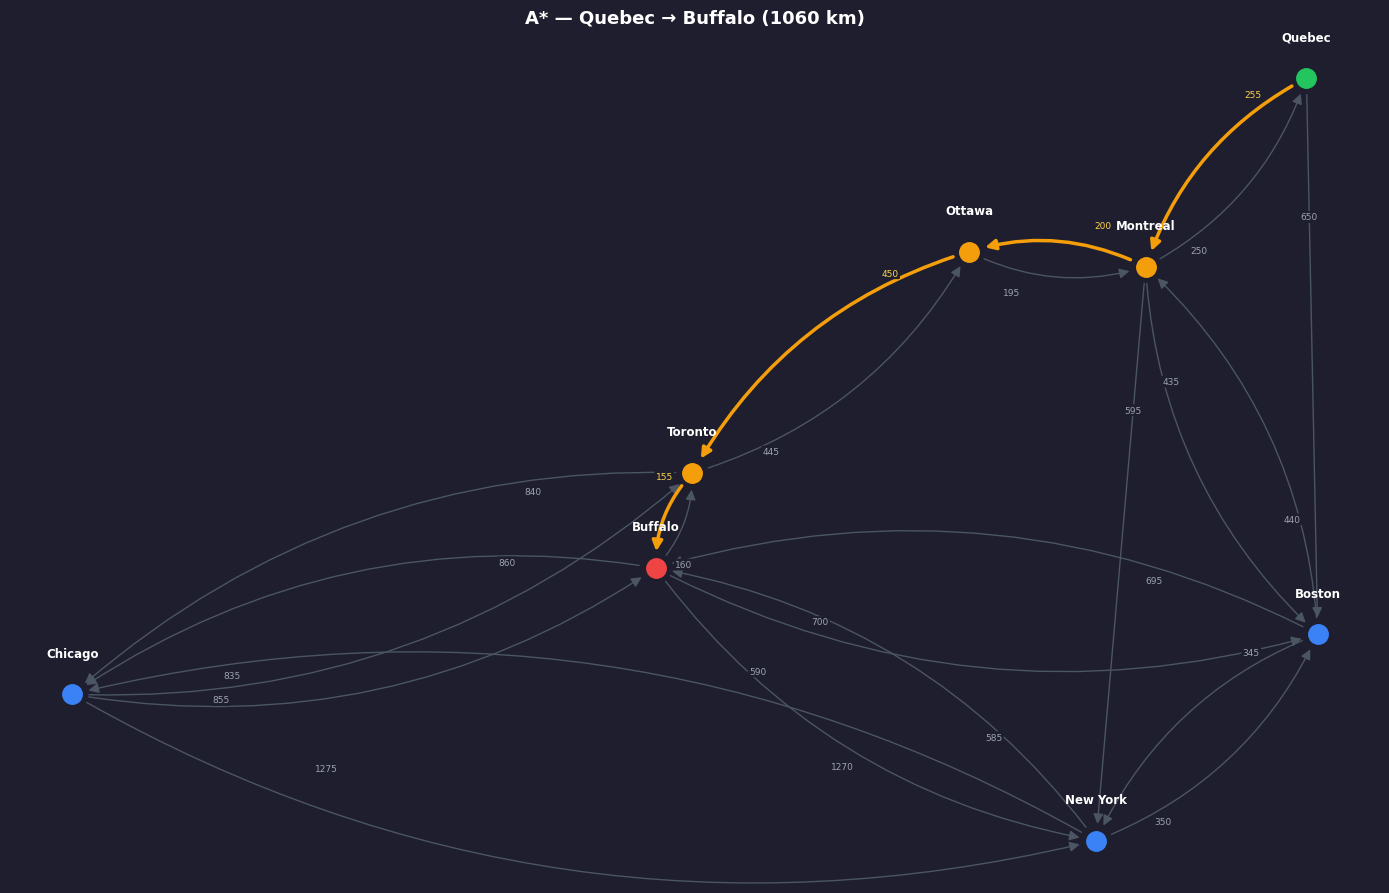

In [ ]:
import matplotlib.pyplot as plt

def visualiser_graphe(graphe: GraphOriente, chemin: list = None, titre: str = "Graphe orienté pondéré"):
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.set_facecolor("#1e1e2e")
    fig.patch.set_facecolor("#1e1e2e")

    coords = {ville: (lon, lat) for ville, (lat, lon) in graphe.villes.items()} # x = longitude, y latitude

    arcs_chemin = set() # Arc du chemin solution
    if chemin:
        for i in range(len(chemin) - 1):# Parcours du chemin, arcs à mettre en évidence, -1 pour pas hors limites
            arcs_chemin.add((chemin[i], chemin[i + 1])) #pair des villes consécutives


    for ville, arcs in graphe.adjacences.items(): # Ville et arc sortant
        x1, y1 = coords[ville] # origine
        for voisin, poids in arcs: #arc sortant de originie
            x2, y2 = coords[voisin] #destination
            est_chemin = (ville, voisin) in arcs_chemin # Arc dans solution?

            couleur = "#f59e0b" if est_chemin else "#4b5563"
            lw = 2.5 if est_chemin else 1.0 
            zorder = 3 if est_chemin else 1 

            arc_inverse = any(v == ville for v, _ in graphe.adjacences[voisin]) # Arc retour existe?
            rad = 0.2 if arc_inverse else 0.0

            ax.annotate(
                "",
                xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color=couleur,
                    lw=lw,
                    mutation_scale=15,
                    shrinkA=12, shrinkB=12,
                    connectionstyle=f"arc3,rad={rad}"
                ),
                zorder=zorder
            )

            
            mx = x1 + (x2 - x1) * 0.25
            my = y1 + (y2 - y1) * 0.25

            if arc_inverse:
                dx, dy = x2 - x1, y2 - y1
                longueur = math.sqrt(dx**2 + dy**2)
                if longueur > 0:
                    offset = 0.3
                    px = dy / longueur * offset
                    py = -dx / longueur * offset
                    mx += px
                    my += py

            ax.text(mx, my, f"{poids}", fontsize=6.5,
                    color="#9ca3af" if not est_chemin else "#fcd34d",
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', fc='#1e1e2e', ec='none'),
                    zorder=4)

    for ville, (x, y) in coords.items():
        est_dans_chemin = chemin and ville in chemin
        est_source  = chemin and ville == chemin[0]
        est_destination = chemin and ville == chemin[-1]

        if est_source:
            couleur_noeud = "#22c55e"
        elif est_destination:
            couleur_noeud = "#ef4444"
        elif est_dans_chemin:
            couleur_noeud = "#f59e0b"
        else:
            couleur_noeud = "#3b82f6"

        ax.plot(x, y, 'o', markersize=14, color=couleur_noeud, zorder=5)
        ax.text(x, y + 0.3, ville, fontsize=8.5, color="white",
                ha='center', fontweight='bold', zorder=6)

    ax.set_title(titre, color="white", fontsize=13, fontweight='bold', pad=12)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

chemin, cout, noeuds, temps = a_star(graphe, VILLE_SOURCE, VILLE_DESTINATION)
visualiser_graphe(graphe, chemin, titre=f"A* — {VILLE_SOURCE} → {VILLE_DESTINATION} ({cout} km)")